#### Activity with massive attacks 

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from functools import reduce

import warnings
warnings.filterwarnings('ignore')

In [18]:
daily_path = daily_data
external_path = external_data

In [19]:
war_date = pd.Timestamp('2022-02-24')
months_before = 1   
months_after = 30

start = war_date - pd.DateOffset(months=months_before)
end = war_date + pd.DateOffset(months=months_after)

In [20]:
attack_threshold = 50 
ma_window = 14  

In [21]:
private_cols = ['msg_count', 'audio_count']
public_cols = ['post_count', 'comment_count', 'reaction_count']
feat_cols = private_cols + public_cols


#### Percentile normalization per donor

In [22]:
files_cols = [
    ('donor_daily_message_count.csv', 'donor_daily_message_count', 'msg_count'),
    ('donor_daily_audio.csv', 'donor_daily_audio_count', 'audio_count'),
    ('donor_daily_posts.csv', 'donor_daily_post_count', 'post_count'),
    ('donor_daily_comments.csv', 'donor_daily_comment_count', 'comment_count'),
    ('donor_daily_reactions.csv', 'donor_daily_reaction_count','reaction_count'),
]

dfs = []
for fname, src_col, dst_col in files_cols:
    tmp = pd.read_csv(daily_path / fname)
    tmp['date'] = pd.to_datetime(tmp['date'])
    tmp = tmp.rename(columns={src_col: dst_col})[['donation_id', 'date', dst_col]]
    dfs.append(tmp)

df = reduce(lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'), dfs)
df = df.fillna(0)
df = df[(df['date'] >= start) & (df['date'] <= end)]

for col in feat_cols:
    df[col + '_pct'] = df.groupby('donation_id')[col].rank(pct=True)

pct_cols = [c + '_pct' for c in feat_cols]
daily = df.groupby('date')[pct_cols].mean().reset_index().sort_values('date')

daily['private'] = daily[[c + '_pct' for c in private_cols]].mean(axis=1)
daily['public'] = daily[[c + '_pct' for c in public_cols]].mean(axis=1)

daily['private_ma'] = daily['private'].rolling(ma_window, center=True, min_periods=1).mean()
daily['public_ma'] = daily['public'].rolling(ma_window, center=True, min_periods=1).mean()

print(f'Donors: {df["donation_id"].nunique()}')
print(f'Period: {daily["date"].min().date()} → {daily["date"].max().date()}')

Donors: 24
Period: 2022-01-24 → 2024-08-24


In [23]:
attacks = pd.read_csv(external_path / 'massive_attacks_by_category.csv', low_memory=False)
attacks['date'] = pd.to_datetime(attacks['date_start'])
attacks = attacks[(attacks['date'] >= start) & (attacks['date'] <= end)]
attacks = attacks[attacks['Total'] >= attack_threshold]
print(f'Massive attacks in the window: {len(attacks)}')

Massive attacks in the window: 33


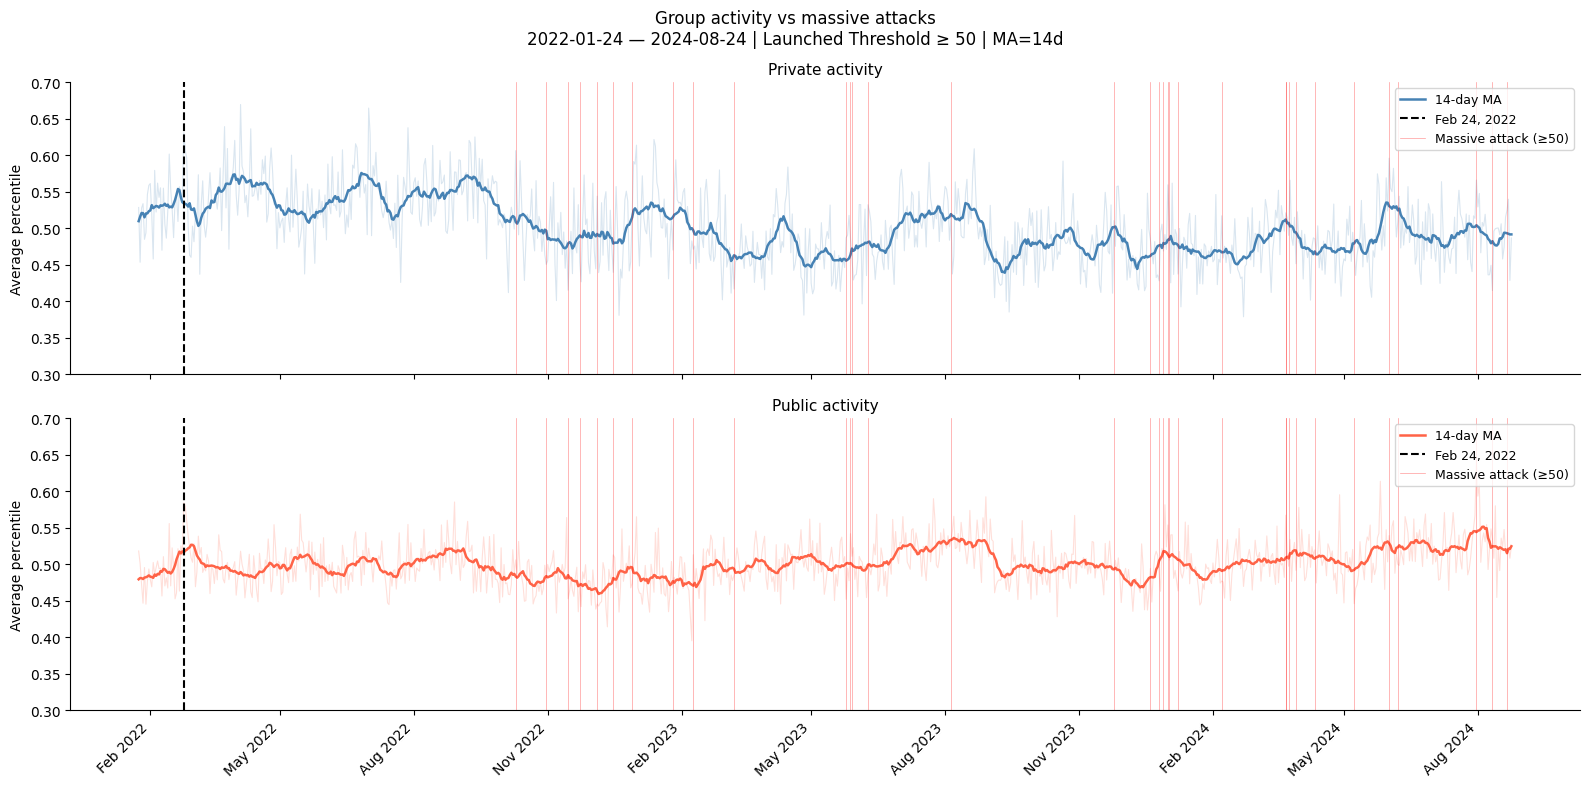

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, raw_col, ma_col, title, color in [
    (ax1, 'private', 'private_ma', 'Private activity', 'steelblue'),
    (ax2, 'public', 'public_ma', 'Public activity', 'tomato'),
]:
    ax.plot(daily['date'], daily[raw_col], color=color, alpha=0.2, linewidth=0.8)

    ax.plot(daily['date'], daily[ma_col], color=color, linewidth=1.8, label=f'{ma_window}-day MA')

    ax.axvline(war_date, color='black', linewidth=1.5, linestyle='--', label='Feb 24, 2022')
    
    for d in attacks['date']:
        ax.axvline(d, color='red', linewidth=0.5, alpha=0.4)

    ax.axvline(attacks['date'].iloc[0], color='red', linewidth=0.5, alpha=0.4,
               label=f'Massive attack (≥{attack_threshold})')

    ax.set_ylabel('Average percentile', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(0.3, 0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle(
    f'Group activity vs massive attacks\n'
    f'{start.date()} — {end.date()} | Launched Threshold ≥ {attack_threshold} | MA={ma_window}d',
    fontsize=12
)
plt.tight_layout()
plt.show()
